In [100]:
from matplotlib import pyplot as plt
import matplotlib
import matplotlib.patheffects as pe
import xarray as xr
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import netCDF4 as nc
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from pathlib import Path
from matplotlib.patches import Rectangle, FancyArrowPatch
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from glob import glob
import os
import sys
import datetime

sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'

from zhiyi.plot.Plot_2D import Plot_2D
from matplotlib.ticker import FuncFormatter
print('done')


done


In [101]:


dates = ['2018-05-27', '2018-05-28', '2018-05-29', '2018-05-30']

scrip_ne30 = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
scrip_ne60 = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc"

map_files_ne30 = sorted(glob(
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/"
    "MUSICA_production3.2_BB.cam.h3.2018-05-??-00000.nc"
))
map_files_ne60 = sorted(glob(
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/"
    "MUSICAv0_ne60_production.cam.h3.2018-05-??-00000.nc"
))

cities = ['London', 'Exeter', 'Cardiff', 'Birmingham',
          'Manchester', 'Sheffield', 'Edinburgh', 'Belfast']

vars_model = {
    r'PM$_{2.5}$': 'PM25',
    r'O$_3$': 'O3',
    'BC': 'BURDENBCdn',
}

configs = [
    {'name': 'ne30x16',
     'se_base_files': (
         "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/"
         "MUSICA_production3.2_BB/atm/hist/"
         "MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc"
     ),
     'scrip_file': scrip_ne30,
     'start_date': datetime.date(2018, 5, 27),
     'end_date': datetime.date(2018, 5, 30),
     'city_lonlat': {'London': [360 - 0.1319, 51.4947],
                     'Exeter': [360 - 3.5325, 50.7251],
                     'Cardiff': [360 - 3.1763, 51.4817],
                     'Birmingham': [360 - 1.9182, 52.4813],
                     'Manchester': [360 - 2.2379, 53.4815],
                     'Sheffield': [360 - 1.4781, 53.3786],
                     'Edinburgh': [360 - 3.1822, 55.9456],
                     'Belfast': [360 - 5.9288, 54.5997]}},
    {'name': 'ne60',
     'se_base_files': (
         "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/"
         "MUSICAv0_ne60_production.cam.h2.2018-MM-DD-03600.nc"
     ),
     'scrip_file': scrip_ne60,
     'start_date': datetime.date(2018, 5, 27),
     'end_date': datetime.date(2018, 5, 30),
     'city_lonlat': {'London': [360 - 0.1319, 51.4947],
                     'Exeter': [360 - 3.5325, 50.7251],
                     'Cardiff': [360 - 3.1763, 51.4817],
                     'Birmingham': [360 - 1.9182, 52.4813],
                     'Manchester': [360 - 2.2379, 53.4815],
                     'Sheffield': [360 - 1.4781, 53.3786],
                     'Edinburgh': [360 - 3.1822, 55.9456],
                     'Belfast': [360 - 5.9288, 54.5997]}},
    {'name': 'regrid',
     'se_base_files': (
         "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/regrid/regridded/"
         "regrid_to_ne60_MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc"
     ),
     'scrip_file': scrip_ne60,
     'start_date': datetime.date(2018, 5, 27),
     'end_date': datetime.date(2018, 5, 30),
     'city_lonlat': {'London': [360 - 0.1319, 51.4947],
                     'Exeter': [360 - 3.5325, 50.7251],
                     'Cardiff': [360 - 3.1763, 51.4817],
                     'Birmingham': [360 - 1.9182, 52.4813],
                     'Manchester': [360 - 2.2379, 53.4815],
                     'Sheffield': [360 - 1.4781, 53.3786],
                     'Edinburgh': [360 - 3.1822, 55.9456],
                     'Belfast': [360 - 5.9288, 54.5997]}},
]


In [102]:
class HandlerBoxPlot(HandlerBase):
    def __init__(self,
                 sx=1.0, sy=1.8, lw=2.0,
                 box_h_frac=0.75, box_w_frac=0.55,
                 whisk_out_frac=0.35, cap_hfrac=0.30,
                 edgecolor='k', median_color='orange',
                 whisker_color='k', cap_color='k',
                 whisker_linestyle='--',
                 **kwargs):
        super().__init__(**kwargs)
        self.sx = sx
        self.sy = sy
        self.lw = lw
        self.box_h_frac = box_h_frac
        self.box_w_frac = box_w_frac
        self.whisk_out_frac = whisk_out_frac
        self.cap_hfrac = cap_hfrac
        self.edgecolor = edgecolor
        self.median_color = median_color
        self.whisker_color = whisker_color
        self.cap_color = cap_color
        self.whisker_linestyle = whisker_linestyle

    def create_artists(self, legend, orig_handle, x0, y0, w, h, fontsize, trans):
        xc, yc = x0 + w/2, y0 + h/2
        w *= self.sx
        h *= self.sy
        x0 = xc - w/2
        y0 = yc - h/2
        box_w = w * self.box_w_frac
        box_h = h * self.box_h_frac
        box_x = x0 + (w - box_w) / 2
        box_y = y0 + (h - box_h) / 2
        whisk = box_w * self.whisk_out_frac
        y_mid = y0 + h / 2
        chf = self.cap_hfrac

        box = Rectangle((box_x, box_y), box_w, box_h,
                        fill=False, edgecolor=self.edgecolor,
                        lw=self.lw, transform=trans)
        med = Line2D([box_x + box_w/2, box_x + box_w/2],
                     [box_y, box_y + box_h], color=self.median_color,
                     lw=self.lw, transform=trans)
        wl = Line2D([box_x - whisk, box_x], [y_mid, y_mid],
                    color=self.whisker_color, lw=self.lw,
                    linestyle=self.whisker_linestyle, transform=trans)
        wr = Line2D([box_x + box_w, box_x + box_w + whisk], [y_mid, y_mid],
                    color=self.whisker_color, lw=self.lw,
                    linestyle=self.whisker_linestyle, transform=trans)
        capl = Line2D([box_x - whisk, box_x - whisk],
                      [y_mid - chf*h/2, y_mid + chf*h/2],
                      color=self.cap_color, lw=self.lw, transform=trans)
        capr = Line2D([box_x + box_w + whisk, box_x + box_w + whisk],
                      [y_mid - chf*h/2, y_mid + chf*h/2],
                      color=self.cap_color, lw=self.lw, transform=trans)
        return [wl, wr, capl, capr, box, med]


def lon_formatter(x, pos=None):
    if x == 0:
        return "0°"
    if x > 0:
        return f"{x:.0f}°E"
    return f"{abs(x):.0f}°W"


def lat_formatter(y, pos=None):
    if y == 0:
        return "0°"
    if y > 0:
        return f"{y:.1f}°N"
    return f"{abs(y):.1f}°S"


def load_and_compute_stats(config, cities, vars_model, box_deg=1.0, buffer_deg=0.2):
    grid = xr.open_dataset(config['scrip_file'])
    lon360 = grid['grid_center_lon'].values
    lat = grid['grid_center_lat'].values
    lon180 = (lon360 + 180) % 360 - 180
    half = box_deg / 2.0 + buffer_deg

    start_date, end_date = config['start_date'], config['end_date']
    se_files = []
    cur = start_date
    while cur <= end_date:
        mm, dd = cur.strftime("%m"), cur.strftime("%d")
        fp = config['se_base_files'].replace("MM", mm).replace("DD", dd)
        if os.path.exists(fp):
            se_files.append(fp)
        else:
            print(f"Warning: skip {fp}")
        cur += datetime.timedelta(days=1)
    if len(se_files) == 0:
        raise FileNotFoundError("No files here")

    ds = xr.open_mfdataset(se_files, combine="by_coords")
    stats = {city: {} for city in cities}

    for city in cities:
        lon360_c, lat_c = config['city_lonlat'][city]
        lon180_c = (lon360_c + 180) % 360 - 180
        diff_lon = (lon180 - lon180_c + 180) % 360 - 180
        mask = (np.abs(lat - lat_c) <= half) & (np.abs(diff_lon) <= half)
        idx = np.where(mask)[0]

        if idx.size == 0:
            dist2 = (lat - lat_c)**2 + (diff_lon)**2
            idx = np.array([np.argmin(dist2)])
            print(f"{city} no point, then cheange to 1")

        for name, var in vars_model.items():
            data_bb = ds[var].values
            if name in ['BC', 'Precipitation']:
                arr = data_bb[:, idx]
            else:
                arr = data_bb[:, -1, idx]
            std = np.nanstd(arr, axis=1)
            mean = np.nanmean(arr, axis=1)
            nsv = np.divide(std, mean,
                            out=np.full_like(mean, np.nan),
                            where=np.isfinite(mean) & (mean != 0))
            stats[city][name] = {'nsv': nsv}

    return stats


In [103]:

daily_ne30 = xr.open_mfdataset(map_files_ne30, combine='by_coords').resample(time="1D").mean(dim="time")
daily_ne60 = xr.open_mfdataset(map_files_ne60, combine='by_coords').resample(time="1D").mean(dim="time")

all_stats = {}
for cfg in configs:
    all_stats[cfg['name']] = load_and_compute_stats(
        cfg, cities, vars_model, box_deg=1.0, buffer_deg=0.2)
pollutants = list(vars_model.keys())


In [104]:
style_dicts = {
    'ne30x16': {
        'facecolor': 'none',
        'edgecolor': 'salmon',
        'box_linewidth': 1.0,
        'median_color': 'darksalmon',
        'median_linewidth': 1.0,
        'whisker_color': 'salmon',
        'whisker_linewidth': 1.0,
        'cap_color': 'salmon',
        'cap_linewidth': 0.9,
        'mean_markeredgecolor': 'salmon',
        'mean_markeredgewidth': 0.8,
        'box_width': 0.25,
    },
    'ne60': {
        'facecolor': 'none',
        'edgecolor': 'cornflowerblue',
        'box_linewidth': 1.0,
        'median_color': 'darkblue',
        'median_linewidth': 1.0,
        'whisker_color': 'cornflowerblue',
        'whisker_linewidth': 1.0,
        'cap_color': 'cornflowerblue',
        'cap_linewidth': 0.9,
        'mean_markeredgecolor': 'cornflowerblue',
        'mean_markeredgewidth': 0.8,
        'box_width': 0.25,
    },
    'regrid': {
        'facecolor': 'none',
        'edgecolor': 'orange',
        'box_linewidth': 1.0,
        'median_color': 'darkorange',
        'median_linewidth': 1.0,
        'whisker_color': 'orange',
        'whisker_linewidth': 1.0,
        'cap_color': 'orange',
        'cap_linewidth': 0.9,
        'mean_markeredgecolor': 'orange',
        'mean_markeredgewidth': 0.8,
        'box_width': 0.25,
    },
}


def draw_pm_map_row(fig, axes, daily, scrip_file, step, letters, grid_name, show_xaxis=True):
    with nc.Dataset(scrip_file) as f:
        lon_scrip = f.variables['grid_center_lon'][:]
        lat_scrip = f.variables['grid_center_lat'][:]

    lon_plot = lon_scrip[::step]
    lat_plot = lat_scrip[::step]
    last_plot = None

    for i, date_str in enumerate(dates):
        ax = axes[i]
        data = daily.sel(time=date_str)['PM25'].isel(lev=-1) * 1e9
        u_plot = daily.sel(time=date_str)['U'].isel(lev=-1).values[::step]
        v_plot = daily.sel(time=date_str)['V'].isel(lev=-1).values[::step]

        last_plot = Plot_2D(
            data,
            scrip_file=scrip_file, pretty_tick=True,
            lon_range=[-9, 9], lat_range=[49.5, 61.5],
            lon_interval=5, lat_interval=5,
            resolution="10m",
            country=True, state=True, title="",
            feature_line_lw=0.15,
            title_bold=True, unit='µg/m³',
            nticks=6,
            title_size=10, label_size=8,
            cmax=40, cmin=0,
            grid_line_lw=0.15,
            lonlat_line=False,
            shrink=0.85, pad=0.055,
            unit_offset=[0.05, 0],
            ax=ax,
            colorbar=False,
        )

        q = ax.quiver(
            lon_plot, lat_plot, u_plot, v_plot,
            scale=180, color='k', width=0.003, alpha=0.9,
            headaxislength=5, headwidth=5, headlength=6, zorder=9,
            transform=ccrs.PlateCarree())

        if i == 3:
            qk_box = Rectangle((0.630, 0.81), 0.38, 0.18,
                               transform=ax.transAxes,
                               facecolor='white', edgecolor='none', zorder=20)
            ax.add_patch(qk_box)
            qk_arrow = FancyArrowPatch(
                (0.63, 0.920), (0.80, 0.920),
                transform=ax.transAxes,
                arrowstyle='-|>', mutation_scale=9.5,
                linewidth=0.76, color='k', zorder=22,
                clip_on=False)
            ax.add_patch(qk_arrow)
            ax.text(0.785, 0.910, '15 m/s',
                    transform=ax.transAxes,
                    fontsize=11, va='center', ha='left',

                    color='k', zorder=22,
                    clip_on=False)

        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='x', which='major', labelsize=14, pad=4, length=4, width=0.7)
        ax.tick_params(axis='x', which='minor', length=1.8, width=0.6)
        ax.tick_params(axis='y', which='major', labelsize=14, pad=4, length=4, width=0.7)
        ax.tick_params(axis='y', which='minor', length=1.8, width=0.6)

        if i == 0:
            ax.tick_params(axis='y', which='both', left=True, right=False, labelleft=True, labelright=False)
        else:
            ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis='x', which='both', bottom=show_xaxis, top=False, labelbottom=show_xaxis)
        ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
        ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))

        ax.text(0.033, 0.95, letters[i], transform=ax.transAxes, zorder=10,
                fontsize=11, va='top', ha='left', weight='bold',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.28', alpha=1))

        day = date_str.split('-')[-1]
        ax.text(0.002, 1.015, f"PM$_{{2.5}}$: 201805{day}",
                transform=ax.transAxes, fontsize=11.5,
                va='bottom', ha='left', weight='bold', zorder=10)

        grid_x = 0.71 if grid_name == r'ne30$\times$16' else 0.85
        ax.text(grid_x, 1.015, grid_name,
                transform=ax.transAxes, fontsize=11.5,
                va='bottom', ha='left', weight='bold', zorder=10)

    return last_plot.im



nsv_yaxis_settings = {
    r'PM$_{2.5}$': {'labelsize': 14, 'pad': 2, 'length': 3, 'width': 0.7,
                    'interval': 25, 'ylim': (0, 133)},
    r'O$_3$': {'labelsize': 14, 'pad': 2, 'length': 3, 'width': 0.7,
               'interval': 15, 'ylim': (0, 48)},
    'BC': {'labelsize': 14, 'pad': 2, 'length': 3, 'width': 0.7,
           'interval': 12, 'ylim': (0, 43)},
}


def draw_nsv_panel(ax, pollutant, panel_letter, show_ylabel=False, show_legend=False):
    yset = nsv_yaxis_settings[pollutant]
    x = np.arange(len(cities))
    for j, cfg in enumerate(configs):
        cfg_name = cfg['name']
        stats = all_stats[cfg_name]
        data = [stats[city][pollutant]['nsv'] * 100 for city in cities]
        sty = style_dicts[cfg_name]
        w = sty['box_width']
        positions = x + (j - 0.5) * w

        ax.boxplot(
            data,
            positions=positions,
            widths=w,
            whis=[0, 100],
            patch_artist=True,
            boxprops=dict(facecolor=sty['facecolor'],
                          edgecolor=sty['edgecolor'],
                          linewidth=sty['box_linewidth']),
            medianprops=dict(color=sty['median_color'],
                             linewidth=sty['median_linewidth']),
            whiskerprops=dict(color=sty['whisker_color'],
                              linewidth=sty['whisker_linewidth'],
                              linestyle='--'),
            capprops=dict(color=sty['cap_color'],
                          linewidth=sty['cap_linewidth']),
            showmeans=True,
            meanprops={
                'marker': 'd',
                'markerfacecolor': sty['mean_markeredgecolor'],
                'markeredgecolor': sty['mean_markeredgecolor'],
                'markeredgewidth': sty['mean_markeredgewidth'],
                'markersize': 3.0,
            })

    ax.set_title(pollutant, fontsize=14, pad=5, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=40, ha='right', fontsize=13)
    ax.tick_params(axis='y', which='major',
                   labelsize=yset['labelsize'], pad=yset['pad'],
                   length=yset['length'], width=yset['width'])
    ax.tick_params(axis='x', which='major', pad=2, length=3, width=0.7)

    if show_ylabel:
        ax.set_ylabel("NSV (%)", fontsize=14, labelpad=1)
    else:
        ax.set_ylabel("")
    ax.yaxis.set_tick_params(labelleft=True, labelright=False, left=True, right=False)

    if yset['interval'] is not None:
        ax.yaxis.set_major_locator(MultipleLocator(yset['interval']))

    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(axis='y', which='minor', length=1.8, width=0.6)

    ax.set_ylim(*yset['ylim'])

    ax.text(0.02, 0.95, panel_letter,
            transform=ax.transAxes, fontsize=11,
            fontweight='bold', va='top', ha='left')

    if show_legend:
        class Ne30Handle: pass
        class Ne60Handle: pass
        class RegridHandle: pass

        handles = [Ne30Handle(), Ne60Handle(), RegridHandle()]
        labels = ['ne30x16', 'ne60', 'ne30x16 (R)']
        handler_map = {
            Ne30Handle: HandlerBoxPlot(
                sx=1.0, sy=1.8, lw=style_dicts['ne30x16']['box_linewidth'],
                box_w_frac=style_dicts['ne30x16']['box_width'] * 1.6,
                whisk_out_frac=style_dicts['ne30x16']['whisker_linewidth'] * 0.3,
                edgecolor=style_dicts['ne30x16']['edgecolor'],
                median_color=style_dicts['ne30x16']['median_color'],
                whisker_color=style_dicts['ne30x16']['whisker_color'],
                cap_color=style_dicts['ne30x16']['cap_color']),
            Ne60Handle: HandlerBoxPlot(
                sx=1.0, sy=1.8, lw=style_dicts['ne60']['box_linewidth'],
                box_w_frac=style_dicts['ne60']['box_width'] * 1.6,
                whisk_out_frac=style_dicts['ne60']['whisker_linewidth'] * 0.3,
                edgecolor=style_dicts['ne60']['edgecolor'],
                median_color=style_dicts['ne60']['median_color'],
                whisker_color=style_dicts['ne60']['whisker_color'],
                cap_color=style_dicts['ne60']['cap_color']),
            RegridHandle: HandlerBoxPlot(
                sx=1.0, sy=1.8, lw=style_dicts['regrid']['box_linewidth'],
                box_w_frac=style_dicts['regrid']['box_width'] * 1.6,
                whisk_out_frac=style_dicts['regrid']['whisker_linewidth'] * 0.3,
                edgecolor=style_dicts['regrid']['edgecolor'],
                median_color=style_dicts['regrid']['median_color'],
                whisker_color=style_dicts['regrid']['whisker_color'],
                cap_color=style_dicts['regrid']['cap_color'],
                whisker_linestyle='--'),
        }
        ax.legend(handles, labels,
                  handler_map=handler_map,
                  loc='upper right', bbox_to_anchor=(1.01, 1),
                  fontsize=9.3, frameon=False,
                  handlelength=2.5, handletextpad=0.25,
                  labelspacing=0.2, borderaxespad=0.0)


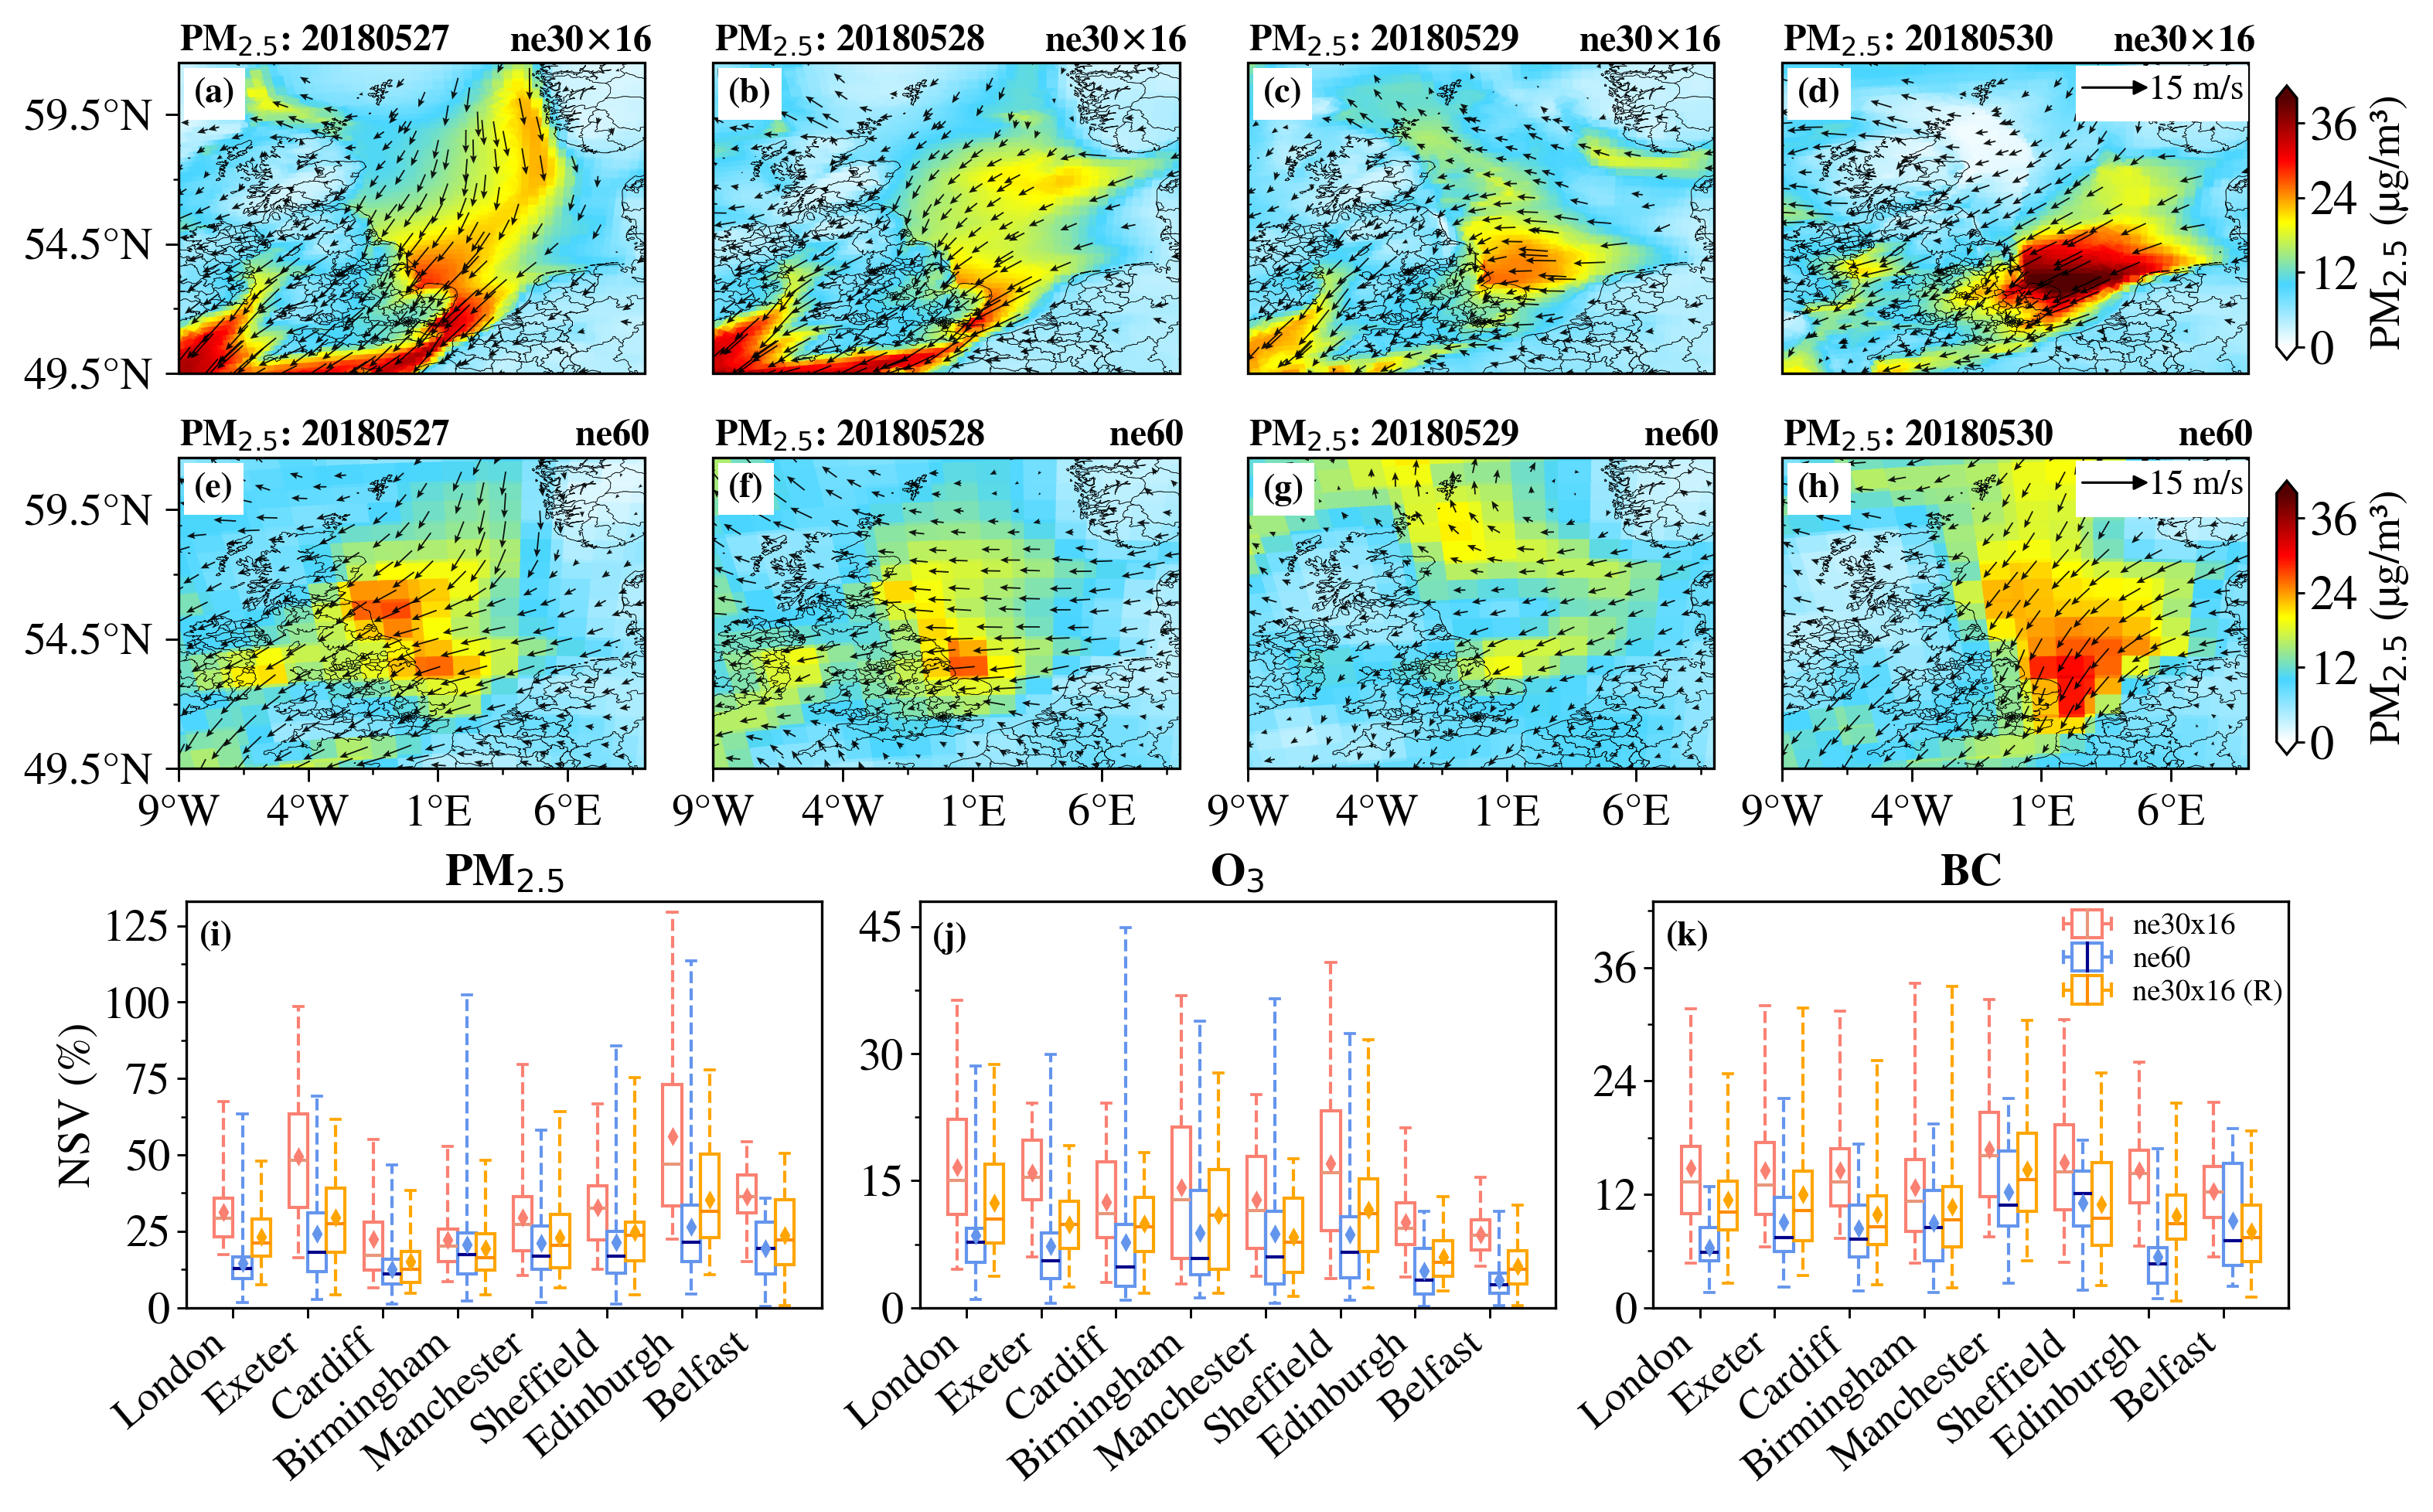

In [105]:


fig = plt.figure(figsize=(10.3, 6.15), dpi=300)

left = 0.055
map_right = 0.935
map_gap = 0.015
map_w = (map_right - left - 3 * map_gap) / 4
map_h = 0.218
map_x = [left + i * (map_w + map_gap) for i in range(4)]

top_y = 0.725
mid_y = 0.448
axs_top = [fig.add_axes([x0, top_y, map_w, map_h], projection=ccrs.PlateCarree()) for x0 in map_x]
axs_mid = [fig.add_axes([x0, mid_y, map_w, map_h], projection=ccrs.PlateCarree()) for x0 in map_x]

bottom_y = 0.070
bottom_h = 0.285
bottom_gap = 0.041
bottom_w = (map_right - left - 2 * bottom_gap) / 3
bottom_x = [left + 0.01 + i * (bottom_w + bottom_gap) for i in range(3)]
axs_bottom = [fig.add_axes([x0, bottom_y, bottom_w, bottom_h]) for x0 in bottom_x]

im_top = draw_pm_map_row(
    fig, axs_top, daily_ne30, scrip_ne30,
    step=75, letters=['(a)', '(b)', '(c)', '(d)'],
    grid_name=r'ne30$\times$16', show_xaxis=False)
im_mid = draw_pm_map_row(
    fig, axs_mid, daily_ne60, scrip_ne60,
    step=2, letters=['(e)', '(f)', '(g)', '(h)'],
    grid_name='ne60', show_xaxis=True)

for cax_y, im in [(top_y + 0.010, im_top), (mid_y + 0.010, im_mid)]:
    cax = fig.add_axes([0.94, cax_y, 0.0085, map_h * 0.88])
    cb = fig.colorbar(im, cax=cax, orientation='vertical',
                      extend='both', ticks=np.arange(0, 42, 12))
    cb.ax.tick_params(labelsize=15, length=2.5, width=0.7, pad=1.5)
    cb.set_label('PM$_{2.5}$ (µg/m³)', fontsize=13.5, labelpad=3)
    cb.ax.yaxis.set_label_position('right')

for ax, pollutant, letter, show_ylabel, show_legend in zip(
        axs_bottom, pollutants, ['(i)', '(j)', '(k)'], [True, False, False], [False, False, True]):
    draw_nsv_panel(ax, pollutant, letter,
                   show_ylabel=show_ylabel,
                   show_legend=show_legend)


In [107]:
figure5_data_path = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/Figure5.nc"
os.makedirs(os.path.dirname(figure5_data_path), exist_ok=True)

map_date = np.array([int(dt.replace('-', '')) for dt in dates], dtype=np.int32)

with xr.open_dataset(scrip_ne30) as grid_ne30, xr.open_dataset(scrip_ne60) as grid_ne60:
    ncol_ne30 = grid_ne30['grid_center_lon'].size
    ncol_ne60 = grid_ne60['grid_center_lon'].size
    ncorner_ne30 = grid_ne30['grid_corner_lon'].shape[1]
    ncorner_ne60 = grid_ne60['grid_corner_lon'].shape[1]

    nsv_lengths = []
    for cfg in configs:
        for pollutant in vars_model:
            for city in cities:
                nsv_lengths.append(len(all_stats[cfg['name']][city][pollutant]['nsv']))
    nsv_sample_count = max(nsv_lengths)
    nsv_values = np.full(
        (len(configs), len(vars_model), len(cities), nsv_sample_count),
        np.nan,
        dtype=np.float64,
    )
    for icfg, cfg in enumerate(configs):
        for ipol, pollutant in enumerate(vars_model):
            for icity, city in enumerate(cities):
                values = np.asarray(all_stats[cfg['name']][city][pollutant]['nsv'], dtype=np.float64) * 100.0
                nsv_values[icfg, ipol, icity, :len(values)] = values

    figure5_ds = xr.Dataset(
        data_vars={
            'pm25_ne30': (('map_date', 'ncol_ne30'),
                          (daily_ne30.sel(time=dates)['PM25'].isel(lev=-1).values * 1e9).astype(np.float64)),
            'u_ne30': (('map_date', 'ncol_ne30'),
                       daily_ne30.sel(time=dates)['U'].isel(lev=-1).values.astype(np.float64)),
            'v_ne30': (('map_date', 'ncol_ne30'),
                       daily_ne30.sel(time=dates)['V'].isel(lev=-1).values.astype(np.float64)),
            'ne30_grid_center_lon': (('ncol_ne30',), grid_ne30['grid_center_lon'].values.astype(np.float64)),
            'ne30_grid_center_lat': (('ncol_ne30',), grid_ne30['grid_center_lat'].values.astype(np.float64)),
            'ne30_grid_corner_lon': (('ncol_ne30', 'grid_corner_ne30'), grid_ne30['grid_corner_lon'].values.astype(np.float64)),
            'ne30_grid_corner_lat': (('ncol_ne30', 'grid_corner_ne30'), grid_ne30['grid_corner_lat'].values.astype(np.float64)),
            'ne30_grid_area': (('ncol_ne30',), grid_ne30['grid_area'].values.astype(np.float64)),

            'pm25_ne60': (('map_date', 'ncol_ne60'),
                          (daily_ne60.sel(time=dates)['PM25'].isel(lev=-1).values * 1e9).astype(np.float64)),
            'u_ne60': (('map_date', 'ncol_ne60'),
                       daily_ne60.sel(time=dates)['U'].isel(lev=-1).values.astype(np.float64)),
            'v_ne60': (('map_date', 'ncol_ne60'),
                       daily_ne60.sel(time=dates)['V'].isel(lev=-1).values.astype(np.float64)),
            'ne60_grid_center_lon': (('ncol_ne60',), grid_ne60['grid_center_lon'].values.astype(np.float64)),
            'ne60_grid_center_lat': (('ncol_ne60',), grid_ne60['grid_center_lat'].values.astype(np.float64)),
            'ne60_grid_corner_lon': (('ncol_ne60', 'grid_corner_ne60'), grid_ne60['grid_corner_lon'].values.astype(np.float64)),
            'ne60_grid_corner_lat': (('ncol_ne60', 'grid_corner_ne60'), grid_ne60['grid_corner_lat'].values.astype(np.float64)),
            'ne60_grid_area': (('ncol_ne60',), grid_ne60['grid_area'].values.astype(np.float64)),

            'nsv': (('nsv_config', 'pollutant', 'city', 'nsv_sample'), nsv_values),
        },
        coords={
            'map_date': map_date,
            'ncol_ne30': np.arange(ncol_ne30, dtype=np.int32),
            'ncol_ne60': np.arange(ncol_ne60, dtype=np.int32),
            'grid_corner_ne30': np.arange(ncorner_ne30, dtype=np.int32),
            'grid_corner_ne60': np.arange(ncorner_ne60, dtype=np.int32),
            'nsv_config': [cfg['name'] for cfg in configs],
            'pollutant': list(vars_model.keys()),
            'city': cities,
            'nsv_sample': np.arange(nsv_sample_count, dtype=np.int32),
        },
    )

for name in list(figure5_ds.data_vars) + list(figure5_ds.coords):
    figure5_ds[name].attrs = {}
figure5_ds.attrs = {}

figure5_ds.to_netcdf(figure5_data_path)
figure5_ds.close()


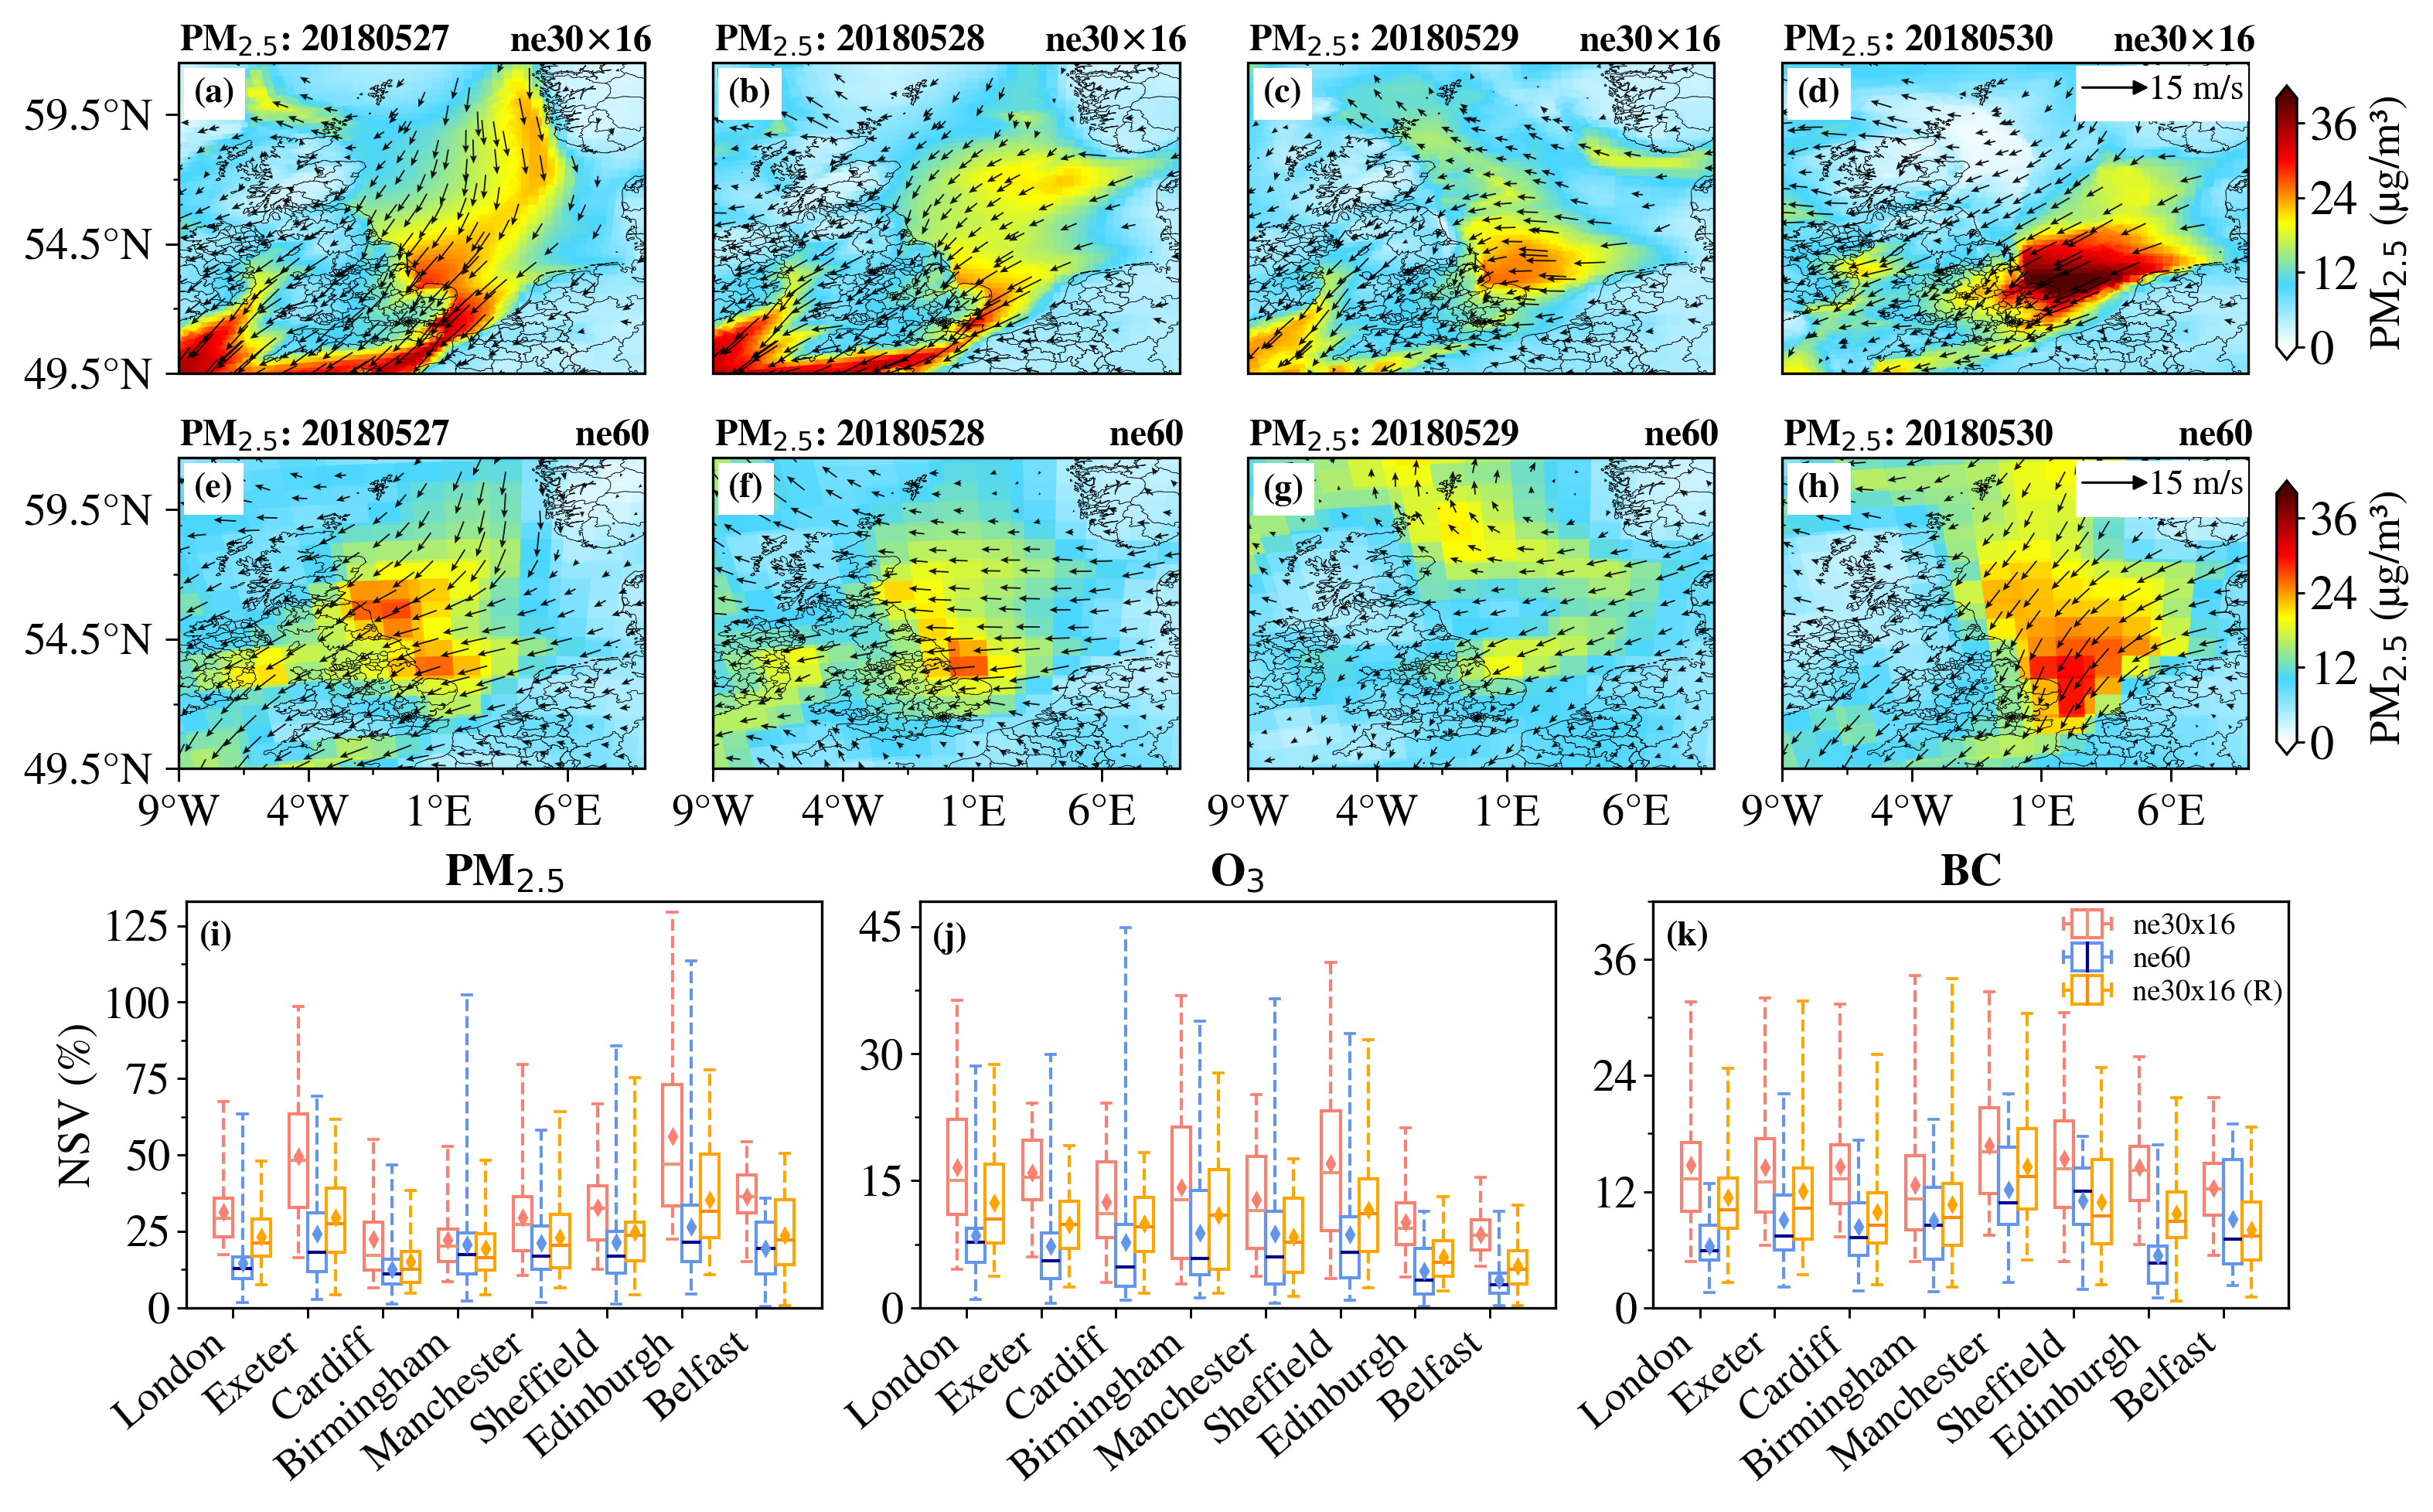

In [ ]:
from matplotlib.patches import Rectangle, FancyArrowPatch

figure5_data_path = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/Figure5.nc"
figure5_saved = xr.open_dataset(figure5_data_path)


def saved_scrip_dataset(ds, grid):
    ncol_dim = f'ncol_{grid}'
    corner_dim = f'grid_corner_{grid}'
    return xr.Dataset({
        'grid_center_lon': ((ncol_dim,), ds[f'{grid}_grid_center_lon'].values),
        'grid_center_lat': ((ncol_dim,), ds[f'{grid}_grid_center_lat'].values),
        'grid_corner_lon': ((ncol_dim, corner_dim), ds[f'{grid}_grid_corner_lon'].values),
        'grid_corner_lat': ((ncol_dim, corner_dim), ds[f'{grid}_grid_corner_lat'].values),
        'grid_area': ((ncol_dim,), ds[f'{grid}_grid_area'].values),
    })


def draw_saved_pm_map_row(fig, axes, ds, grid, step, letters, grid_name, show_xaxis=True):
    scrip_ds = saved_scrip_dataset(ds, grid)
    lon_plot = ds[f'{grid}_grid_center_lon'].values[::step]
    lat_plot = ds[f'{grid}_grid_center_lat'].values[::step]
    last_plot = None

    for i, map_date_value in enumerate(ds['map_date'].values):
        ax = axes[i]
        data = xr.DataArray(ds[f'pm25_{grid}'].isel(map_date=i).values,
                            dims=[f'ncol_{grid}'])
        u_plot = ds[f'u_{grid}'].isel(map_date=i).values[::step]
        v_plot = ds[f'v_{grid}'].isel(map_date=i).values[::step]

        last_plot = Plot_2D(
            data,
            scrip_file=scrip_ds, pretty_tick=True,
            lon_range=[-9, 9], lat_range=[49.5, 61.5],
            lon_interval=5, lat_interval=5,
            resolution="10m",
            country=True, state=True, title="",
            feature_line_lw=0.15,
            title_bold=True, unit='µg/m³',
            nticks=6,
            title_size=10, label_size=8,
            cmax=40, cmin=0,
            grid_line_lw=0.15,
            lonlat_line=False,
            shrink=0.85, pad=0.055,
            unit_offset=[0.05, 0],
            ax=ax,
            colorbar=False,
        )

        q = ax.quiver(
            lon_plot, lat_plot, u_plot, v_plot,
            scale=180, color='k', width=0.003, alpha=0.9,
            headaxislength=5, headwidth=5, headlength=6, zorder=9,
            transform=ccrs.PlateCarree())

        if i == 3:
            qk_box = Rectangle((0.630, 0.81), 0.38, 0.18,
                               transform=ax.transAxes,
                               facecolor='white', edgecolor='none', zorder=20)
            ax.add_patch(qk_box)
            qk_arrow = FancyArrowPatch(
                (0.63, 0.920), (0.80, 0.920),
                transform=ax.transAxes,
                arrowstyle='-|>', mutation_scale=9.5,
                linewidth=0.76, color='k', zorder=22,
                clip_on=False)
            ax.add_patch(qk_arrow)
            ax.text(0.785, 0.910, '15 m/s',
                    transform=ax.transAxes,
                    fontsize=11, va='center', ha='left',

                    color='k', zorder=22,
                    clip_on=False)

        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='x', which='major', labelsize=14, pad=4, length=4, width=0.7)
        ax.tick_params(axis='x', which='minor', length=1.8, width=0.6)
        ax.tick_params(axis='y', which='major', labelsize=14, pad=4, length=4, width=0.7)
        ax.tick_params(axis='y', which='minor', length=1.8, width=0.6)

        if i == 0:
            ax.tick_params(axis='y', which='both', left=True, right=False, labelleft=True, labelright=False)
        else:
            ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis='x', which='both', bottom=show_xaxis, top=False, labelbottom=show_xaxis)
        ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
        ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))

        ax.text(0.033, 0.95, letters[i], transform=ax.transAxes, zorder=10,
                fontsize=11, va='top', ha='left', weight='bold',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.28', alpha=1))
        ax.text(0.002, 1.015, f"PM$_{{2.5}}$: {int(map_date_value)}",
                transform=ax.transAxes, fontsize=11.5,
                va='bottom', ha='left', weight='bold', zorder=10)

        grid_x = 0.71 if grid_name == r'ne30$\times$16' else 0.85
        ax.text(grid_x, 1.015, grid_name,
                transform=ax.transAxes, fontsize=11.5,
                va='bottom', ha='left', weight='bold', zorder=10)

    return last_plot.im


nsv_yaxis_settings = {
    r'PM$_{2.5}$': {'labelsize': 14, 'pad': 2, 'length': 3, 'width': 0.7,
                    'interval': 25, 'ylim': (0, 133)},
    r'O$_3$': {'labelsize': 14, 'pad': 2, 'length': 3, 'width': 0.7,
               'interval': 15, 'ylim': (0, 48)},
    'BC': {'labelsize': 14, 'pad': 2, 'length': 3, 'width': 0.7,
           'interval': 12, 'ylim': (0, 42)},
}


def draw_saved_nsv_panel(ax, ds, pollutant, panel_letter, show_ylabel=False, show_legend=False):
    yset = nsv_yaxis_settings[pollutant]
    x = np.arange(len(cities))
    for j, cfg in enumerate(configs):
        cfg_name = cfg['name']
        sty = style_dicts[cfg_name]
        w = sty['box_width']
        positions = x + (j - 0.5) * w
        data = []
        for city in cities:
            values = ds['nsv'].sel(nsv_config=cfg_name, pollutant=pollutant, city=city).values
            data.append(values[np.isfinite(values)])

        ax.boxplot(
            data,
            positions=positions,
            widths=w,
            whis=[0, 100],
            patch_artist=True,
            boxprops=dict(facecolor=sty['facecolor'],
                          edgecolor=sty['edgecolor'],
                          linewidth=sty['box_linewidth']),
            medianprops=dict(color=sty['median_color'],
                             linewidth=sty['median_linewidth']),
            whiskerprops=dict(color=sty['whisker_color'],
                              linewidth=sty['whisker_linewidth'],
                              linestyle='--'),
            capprops=dict(color=sty['cap_color'],
                          linewidth=sty['cap_linewidth']),
            showmeans=True,
            meanprops={
                'marker': 'd',
                'markerfacecolor': sty['mean_markeredgecolor'],
                'markeredgecolor': sty['mean_markeredgecolor'],
                'markeredgewidth': sty['mean_markeredgewidth'],
                'markersize': 3.0,
            })

    ax.set_title(pollutant, fontsize=14, pad=5, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=40, ha='right', fontsize=13)
    ax.tick_params(axis='y', which='major',
                   labelsize=yset['labelsize'], pad=yset['pad'],
                   length=yset['length'], width=yset['width'])
    ax.tick_params(axis='x', which='major', pad=2, length=3, width=0.7)

    if show_ylabel:
        ax.set_ylabel("NSV (%)", fontsize=14, labelpad=1)
    else:
        ax.set_ylabel("")
    ax.yaxis.set_tick_params(labelleft=True, labelright=False, left=True, right=False)

    if yset['interval'] is not None:
        ax.yaxis.set_major_locator(MultipleLocator(yset['interval']))

    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(axis='y', which='minor', length=1.8, width=0.6)

    ax.set_ylim(*yset['ylim'])

    ax.text(0.02, 0.95, panel_letter,
            transform=ax.transAxes, fontsize=11,
            fontweight='bold', va='top', ha='left')

    if show_legend:
        class Ne30Handle: pass
        class Ne60Handle: pass
        class RegridHandle: pass

        handles = [Ne30Handle(), Ne60Handle(), RegridHandle()]
        labels = ['ne30x16', 'ne60', 'ne30x16 (R)']
        handler_map = {
            Ne30Handle: HandlerBoxPlot(
                sx=1.0, sy=1.8, lw=style_dicts['ne30x16']['box_linewidth'],
                box_w_frac=style_dicts['ne30x16']['box_width'] * 1.6,
                whisk_out_frac=style_dicts['ne30x16']['whisker_linewidth'] * 0.3,
                edgecolor=style_dicts['ne30x16']['edgecolor'],
                median_color=style_dicts['ne30x16']['median_color'],
                whisker_color=style_dicts['ne30x16']['whisker_color'],
                cap_color=style_dicts['ne30x16']['cap_color']),
            Ne60Handle: HandlerBoxPlot(
                sx=1.0, sy=1.8, lw=style_dicts['ne60']['box_linewidth'],
                box_w_frac=style_dicts['ne60']['box_width'] * 1.6,
                whisk_out_frac=style_dicts['ne60']['whisker_linewidth'] * 0.3,
                edgecolor=style_dicts['ne60']['edgecolor'],
                median_color=style_dicts['ne60']['median_color'],
                whisker_color=style_dicts['ne60']['whisker_color'],
                cap_color=style_dicts['ne60']['cap_color']),
            RegridHandle: HandlerBoxPlot(
                sx=1.0, sy=1.8, lw=style_dicts['regrid']['box_linewidth'],
                box_w_frac=style_dicts['regrid']['box_width'] * 1.6,
                whisk_out_frac=style_dicts['regrid']['whisker_linewidth'] * 0.3,
                edgecolor=style_dicts['regrid']['edgecolor'],
                median_color=style_dicts['regrid']['median_color'],
                whisker_color=style_dicts['regrid']['whisker_color'],
                cap_color=style_dicts['regrid']['cap_color'],
                whisker_linestyle='--'),
        }
        ax.legend(handles, labels,
                  handler_map=handler_map,
                  loc='upper right', bbox_to_anchor=(1.01, 1),
                  fontsize=9.3, frameon=False,
                  handlelength=2.5, handletextpad=0.25,
                  labelspacing=0.2, borderaxespad=0.0)


fig = plt.figure(figsize=(10.3, 6.15), dpi=300)

left = 0.055
map_right = 0.935
map_gap = 0.015
map_w = (map_right - left - 3 * map_gap) / 4
map_h = 0.218
map_x = [left + i * (map_w + map_gap) for i in range(4)]

top_y = 0.725
mid_y = 0.448
axs_top = [fig.add_axes([x0, top_y, map_w, map_h], projection=ccrs.PlateCarree()) for x0 in map_x]
axs_mid = [fig.add_axes([x0, mid_y, map_w, map_h], projection=ccrs.PlateCarree()) for x0 in map_x]

bottom_y = 0.070
bottom_h = 0.285
bottom_gap = 0.041
bottom_w = (map_right - left - 2 * bottom_gap) / 3

bottom_x = [left + 0.01 + i * (bottom_w + bottom_gap) for i in range(3)]
axs_bottom = [fig.add_axes([x0, bottom_y, bottom_w, bottom_h]) for x0 in bottom_x]

im_top = draw_saved_pm_map_row(
    fig, axs_top, figure5_saved, 'ne30',
    step=75, letters=['(a)', '(b)', '(c)', '(d)'],
    grid_name=r'ne30$\times$16', show_xaxis=False)
im_mid = draw_saved_pm_map_row(
    fig, axs_mid, figure5_saved, 'ne60',
    step=2, letters=['(e)', '(f)', '(g)', '(h)'],
    grid_name='ne60', show_xaxis=True)

for cax_y, im in [(top_y + 0.010, im_top), (mid_y + 0.010, im_mid)]:
    cax = fig.add_axes([0.94, cax_y, 0.0085, map_h * 0.88])
    cb = fig.colorbar(im, cax=cax, orientation='vertical',
                      extend='both', ticks=np.arange(0, 42, 12))
    cb.ax.tick_params(labelsize=15, length=2.5, width=0.7, pad=1.5)
    cb.set_label('PM$_{2.5}$ (µg/m³)', fontsize=13.5, labelpad=3)
    cb.ax.yaxis.set_label_position('right')

for ax, pollutant, letter, show_ylabel, show_legend in zip(
        axs_bottom, pollutants, ['(i)', '(j)', '(k)'], [True, False, False], [False, False, True]):
    draw_saved_nsv_panel(ax, figure5_saved, pollutant, letter,
                         show_ylabel=show_ylabel,
                         show_legend=show_legend)



